In [10]:
import re
import warnings
from collections import Counter

import nltk
import numpy as np
import pandas as pd
from nltk import word_tokenize
from nltk.corpus import stopwords

warnings.filterwarnings("ignore")

nltk.download('stopwords')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('russian'))

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Ruslan\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [11]:
def tokenize(text):
    """Токенизирует входящий текст"""
    text = text.lower()
    text = re.sub(r'[^а-яa-z\s]', '', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]
    return tokens


df = pd.read_csv("../events/2_struct/2000-2025.csv")  #
df["tokens"] = df["event"].apply(tokenize)
df.head()

,date_start,date_end,event,tokens
0,2000-01-01,NaN,Деноминация белорусского рубля;,"[деноминация, белорусского, рубля]"
1,2000-01-01,NaN,"В связи с «проблемой-2000», в Иране объявлен н...","[связи, проблемой, иране, объявлен, нерабочий,..."
2,2000-01-01,NaN,"Вступление в силу закона в Великобритании, сог...","[вступление, силу, закона, великобритании, сог..."
3,2000-01-02,NaN,Крушение украинского сухогруза типа «река-море...,"[крушение, украинского, сухогруза, типа, рекам..."
4,2000-01-03,NaN,Обстрел из гранатомёта территории российского ...,"[обстрел, гранатомта, территории, российского,..."


In [12]:
from gensim.models import Word2Vec

corpus = df["tokens"].tolist()

total_words = sum(len(tokens) for tokens in corpus)
print(f"Всего слов (токенов): {total_words}")

unique_words = len(set(word for tokens in corpus for word in tokens))
print(f"Уникальных слов: {unique_words}")

corpus[0]

Всего слов (токенов): 62005
Уникальных слов: 17626


['деноминация', 'белорусского', 'рубля']

In [13]:
def vectorize(tokens, model):
    """
    Преобразует список токенов в один вектор события на основе обученной модели Word2Vec.
    """
    vectors = [model.wv[w] for w in tokens if w in model.wv]
    if not vectors:
        return np.zeros(model.vector_size)
    return np.mean(vectors, axis=0)  # вопросы по поводу среднего, почему берем именно среднее?


model = Word2Vec(
    sentences=corpus,
    vector_size=100,  # размерность векторов
    window=5,
    min_count=2,
    sg=1,  # skip-gram,
    epochs=20,
    seed=42
)
df["vector"] = df["tokens"].apply(lambda t: vectorize(t, model))
X = np.vstack(df["vector"].values)
X.shape

(5649, 100)

In [17]:
from sklearn.preprocessing import normalize
import hdbscan

# 1️⃣ Нормализуем векторы (каждый до единичной длины)
X_norm = normalize(X, norm='l2')

# 2️⃣ Обучаем HDBSCAN с метрикой cosine
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    metric='cosine',
    algorithm='generic',
)

# 3️⃣ Кластеризация
labels = clusterer.fit_predict(X_norm)
df["cluster"] = labels

# 4️⃣ Проверяем результат
print("Количество кластеров:", len(set(labels)) - (1 if -1 in labels else 0))

Количество кластеров: 56


In [18]:
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = Counter(tokens).most_common(10)
    print(f"\nКластер {cluster_id}: {[w for w, _ in common]}")


Кластер -1: ['выборы', 'сша', 'президента', 'россии', 'президент', 'года', 'победу', 'парламентские', 'выборов', 'страны']

Кластер 0: ['дипломатические', 'отношения', 'установили', 'разорвала', 'отношение', 'узбекистан', 'установлены', 'бутан', 'украина', 'арменией']

Кластер 1: ['перепись', 'населения', 'прошла', 'украине', 'всероссийская', 'республике', 'эстонии', 'сша', 'болгарии', 'литве']

Кластер 2: ['игр', 'олимпийских', 'летних', 'года', 'зимних', 'церемония', 'токио', 'проведение', 'столицей', 'открытия']

Кластер 3: ['церемония', 'состоялась', 'вручения', 'прошла', 'лосанджелесе', 'оскар', 'лучшим', 'фильмом', 'папы', 'римского']

Кластер 4: ['единый', 'день', 'голосования', 'россии', 'прошл', 'первый', 'второй', 'десятый', 'россия', 'беларуси']

Кластер 5: ['оон', 'безопасности', 'совет', 'резолюцию', 'принял', 'единогласно', 'вывода', 'израильских', 'ливана', 'израиль']

Кластер 6: ['православной', 'церкви', 'собор', 'русской', 'украине', 'церковь', 'архиерейский', 'патри

In [23]:
print("==================== События по кластерам ====================")
for cluster_id in sorted(df["cluster"].unique()):
    subset = df[df["cluster"] == cluster_id]

    print(f"🟩 Кластер {cluster_id} ({len(subset)} событий)")
    for event in subset["event"].head(10):  # показываем первые 10 событий
        print(f"  - {event}")

    tokens = [t for tokens in subset["tokens"] for t in tokens]
    common = [w for w, _ in Counter(tokens).most_common(10)]
    print(f"  🗝️ Ключевые слова: {common}")

==================== События по кластерам ====================
🟩 Кластер -1 (3392 событий)
  - В связи с «проблемой-2000», в Иране объявлен нерабочий день;
  - Вступление в силу закона в Великобритании, согласно которому вес всех продуктов, имеющихся в продаже, обозначается в метрической системе, а не в традиционных для страны унциях и фунтах.
  - Обстрел из гранатомёта территории российского посольства в Ливане, Бейрут;
  - Победа коалиции социал-демократов-социал-либералов, вместе с блоком из четырёх других партий (во главе с Крестьянской партией) на парламентских выборах в Хорватии, набравших две трети голосов в парламенте, что в дальнейшем позволило изменить конституцию и превратить республику из полу-президентской в парламентскую.
  - Первая рождественская литургия в храме христа спасителя. литургию отслужил патриарх московский и всея руси алексий ii.
  - Переизбрание Ислама Каримова президентом Республики Узбекистан (91,9 % голосов избирателей);
  - Вторая чеченская война: прорыв

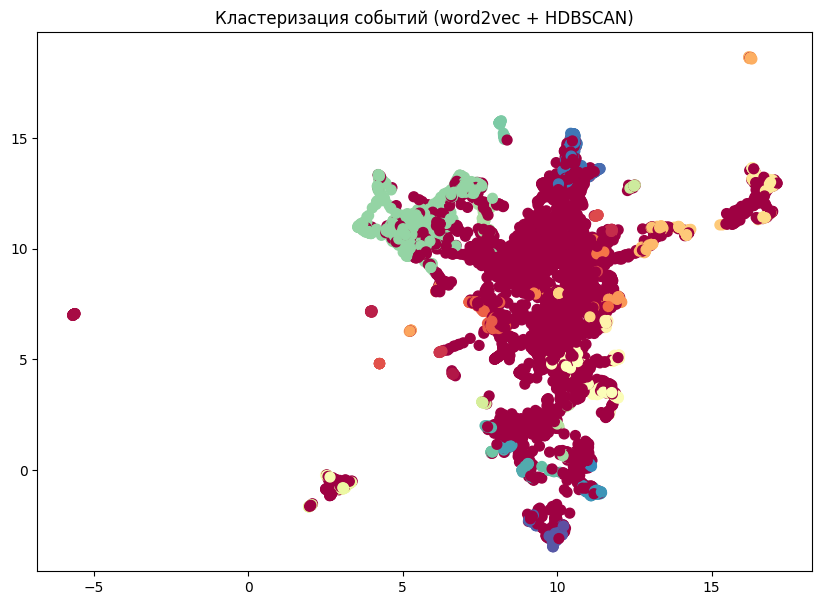

In [24]:
import umap
import matplotlib.pyplot as plt

umap_embeddings = umap.UMAP(n_neighbors=15, min_dist=0.1).fit_transform(X_norm)

plt.figure(figsize=(10, 7))
plt.scatter(umap_embeddings[:, 0], umap_embeddings[:, 1],
            c=df["cluster"], cmap="Spectral", s=50)
plt.title("Кластеризация событий (word2vec + HDBSCAN)")
plt.show()

In [41]:
from sklearn.metrics import silhouette_score

mask = labels != -1
score = silhouette_score(X[mask], labels[mask])
score

0.3321906603991286

In [52]:
import itertools
import numpy as np
import pandas as pd
from gensim.models import Word2Vec
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
import hdbscan
from tqdm import tqdm

# ==== 3. Пространство гиперпараметров ====
param_grid = {
    "vector_size": [100, 200, 300],
    "window": [3, 5, 8, 10],
    "min_count": [1, 2, 5],
    "sg": [0, 1],  # 0 — CBOW, 1 — Skip-gram
}

param_combinations = list(itertools.product(*param_grid.values()))
param_names = list(param_grid.keys())

results = []

# ==== 4. Перебор параметров ====
for params in tqdm(param_combinations, desc="Grid Search Word2Vec"):
    param_dict = dict(zip(param_names, params))

    # 4.1 Обучаем Word2Vec
    model = Word2Vec(
        sentences=corpus,
        **param_dict,
        workers=4,
        epochs=20,
        seed=42
    )

    # 4.2 Векторизация событий
    X = np.vstack([vectorize(tokens, model) for tokens in corpus])
    X_norm = normalize(X, norm='l2')
    # 4.3 Кластеризация (можно выбрать KMeans или HDBSCAN)
    # HDBSCAN (автоматически подбирает число кластеров)
    clusterer = hdbscan.HDBSCAN(
        min_cluster_size=10,
        min_samples=3,
        metric='cosine',
        algorithm='generic',
    )
    labels = clusterer.fit_predict(X_norm)

    # Игнорируем шумовые точки (-1)
    mask = labels != -1
    if len(set(labels[mask])) < 2:
        continue

    # ==== 4.4 Метрики ====
    sil = silhouette_score(X_norm[mask], labels[mask])
    db = davies_bouldin_score(X_norm[mask], labels[mask])
    ch = calinski_harabasz_score(X_norm[mask], labels[mask])

    results.append({
        **param_dict,
        "silhouette": sil,
        "davies_bouldin": db,
        "calinski_harabasz": ch,
        "clusters": len(set(labels[mask]))
    })

# ==== 5. Анализ результатов ====
results_df = pd.DataFrame(results)
results_df = results_df.sort_values("silhouette", ascending=False)

print("\nЛучшие параметры по silhouette:")
print(results_df.head(10))

# Можно также вывести среднюю оценку с весами
results_df["score_combined"] = (
        results_df["silhouette"] * 2
        - results_df["davies_bouldin"] * 0.5
        + np.log1p(results_df["calinski_harabasz"]) * 0.1
)

print("\nТоп по комбинированному скору:")
results_df.sort_values("score_combined", ascending=False).head(10)

Grid Search Word2Vec: 100%|██████████| 72/72 [03:41<00:00,  3.08s/it]


Лучшие параметры по silhouette:
    vector_size  window  min_count  sg  silhouette  davies_bouldin  \
12          100       8          1   0    0.496553        0.776747   
62          300       8          2   0    0.492676        0.840565   
18          100      10          1   0    0.489516        0.744146   
44          200      10          2   0    0.485882        0.784669   
36          200       8          1   0    0.484715        0.759935   
20          100      10          2   0    0.461195        0.840900   
66          300      10          1   0    0.454270        0.793203   
60          300       8          1   0    0.450932        0.802082   
68          300      10          2   0    0.449528        0.819422   
38          200       8          2   0    0.444728        0.779975   

    calinski_harabasz  clusters  
12        2138.909469        60  
62        1890.971718        61  
18        2074.877482        63  
44        1845.190947        57  
36        2527.790304     

,vector_size,window,min_count,sg,silhouette,davies_bouldin,calinski_harabasz,clusters,score_combined
36,200,8,1,0,0.484715,0.759935,2527.790304,58,1.373011
12,100,8,1,0,0.496553,0.776747,2138.909469,60,1.371585
18,100,10,1,0,0.489516,0.744146,2074.877482,63,1.370773
44,200,10,2,0,0.485882,0.784669,1845.190947,57,1.331517
62,300,8,2,0,0.492676,0.840565,1890.971718,61,1.319607
66,300,10,1,0,0.454270,0.793203,2674.987457,58,1.301146
60,300,8,1,0,0.450932,0.802082,1994.165124,60,1.260671
38,200,8,2,0,0.444728,0.779975,1413.559248,57,1.224927
68,300,10,2,0,0.449528,0.819422,1466.396067,58,1.218469
20,100,10,2,0,0.461195,0.840900,1239.659276,57,1.214281


In [55]:
# === 1. Обучаем Word2Vec с выбранными параметрами ===
best_params = {
    "vector_size": 200,
    "window": 8,
    "min_count": 1,
    "sg": 0,  # Skip-gram
    "workers": 4,
    "epochs": 20,
    "seed": 42
}

model = Word2Vec(sentences=corpus, **best_params)

X = np.vstack([vectorize(tokens, model) for tokens in corpus])
X_norm = normalize(X, norm='l2')

# === 3. Кластеризация (можно поменять min_cluster_size) ===
clusterer = hdbscan.HDBSCAN(
    min_cluster_size=10,
    min_samples=3,
    metric='cosine',
    algorithm='generic',

)
labels = clusterer.fit_predict(X_norm)
df["tokens"] = corpus
df["cluster"] = labels

# === 4. Метрики качества ===
mask = labels != -1
if len(set(labels[mask])) > 1:
    sil = silhouette_score(X_norm[mask], labels[mask])
    db = davies_bouldin_score(X_norm[mask], labels[mask])
    ch = calinski_harabasz_score(X_norm[mask], labels[mask])
    print(f"Silhouette: {sil:.3f}, Davies–Bouldin: {db:.3f}, Calinski–Harabasz: {ch:.1f}")
else:
    print("Недостаточно кластеров для расчёта метрик")

# === 5. Сводка по кластерам ===
print("\n📊 Кластеры:")
print(df["cluster"].value_counts().sort_index())

# === 6. Вывод топ-слов по каждому кластеру ===
for cluster_id in sorted(df["cluster"].unique()):
    if cluster_id == -1:
        continue
    subset = df[df["cluster"] == cluster_id]
    tokens = [t for tokens in subset["tokens"] for t in tokens if t in model.wv]
    top_words = [w for w, _ in Counter(tokens).most_common(30)]
    print(f"\nКластер {cluster_id}: {top_words}")

Silhouette: 0.481, Davies–Bouldin: 0.750, Calinski–Harabasz: 2064.2

📊 Кластеры:
cluster
-1     3359
 0       14
 1       11
 2       17
 3       16
 4       40
 5       45
 6       13
 7       72
 8       13
 9       28
 10      26
 11      44
 12      14
 13      16
 14      13
 15      15
 16      18
 17      43
 18      11
 19      15
 20      17
 21      24
 22      68
 23      68
 24      11
 25      12
 26      15
 27      26
 28      18
 29      15
 30     121
 31      58
 32      24
 33      26
 34      55
 35      40
 36      27
 37      14
 38      11
 39      19
 40      28
 41      53
 42      24
 43      36
 44      15
 45      14
 46      10
 47      29
 48      10
 49      32
 50      12
 51      12
 52      21
 53      12
 54     162
 55      28
 56      23
 57     616
Name: count, dtype: int64

Кластер 0: ['единый', 'день', 'голосования', 'россии', 'десятый', 'прошл', 'беларуси']

Кластер 1: ['форум', 'казахстана', 'россии', 'межрегионального', 'сотрудничества', 'росс